<a href="https://colab.research.google.com/github/agungairlangg635-hue/CRYPTO-SIGNAL-BOT/blob/main/data%20analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'food-delivery-time-prediction' dataset.
Dimensi Data Mentah: (1000, 9)
Dimensi Data Bersih Siap Analisis: (883, 11)


/tmp/ipykernel_2539/65674916.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df, order=valid_traffic, palette='crest')
/tmp/ipykernel_2539/65674916.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Delivery_Time_min', data=df, order=weather_order, palette='mako', errorbar=None)


Analisis Selesai! Mengunduh file CSV dan 4 gambar grafik ke laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

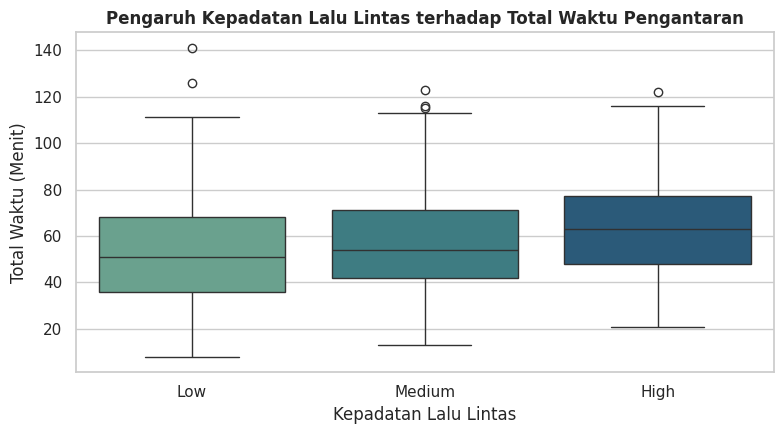

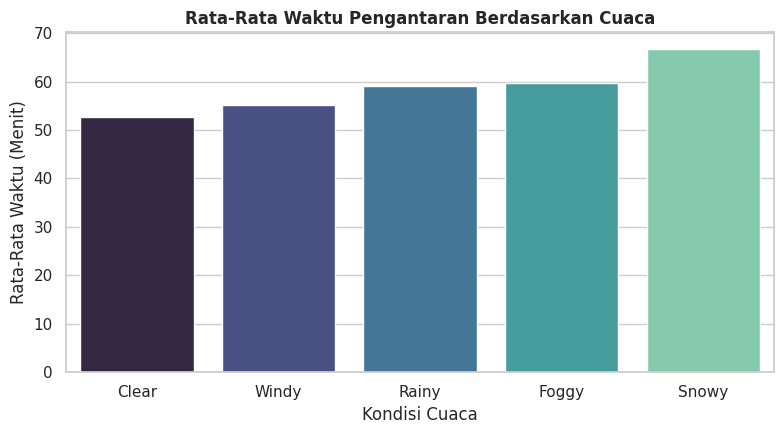

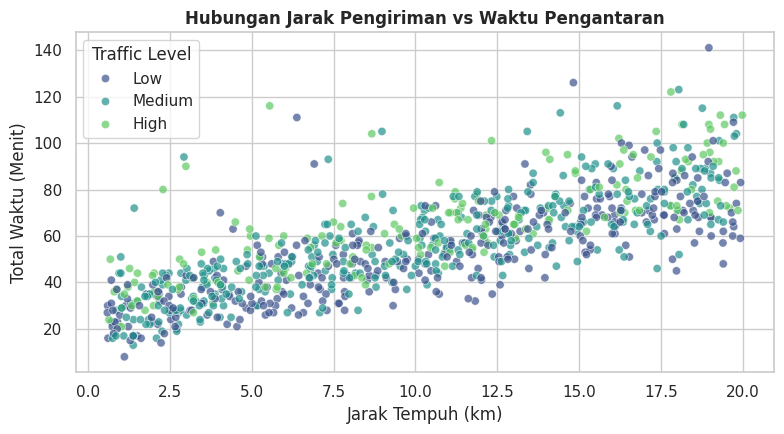

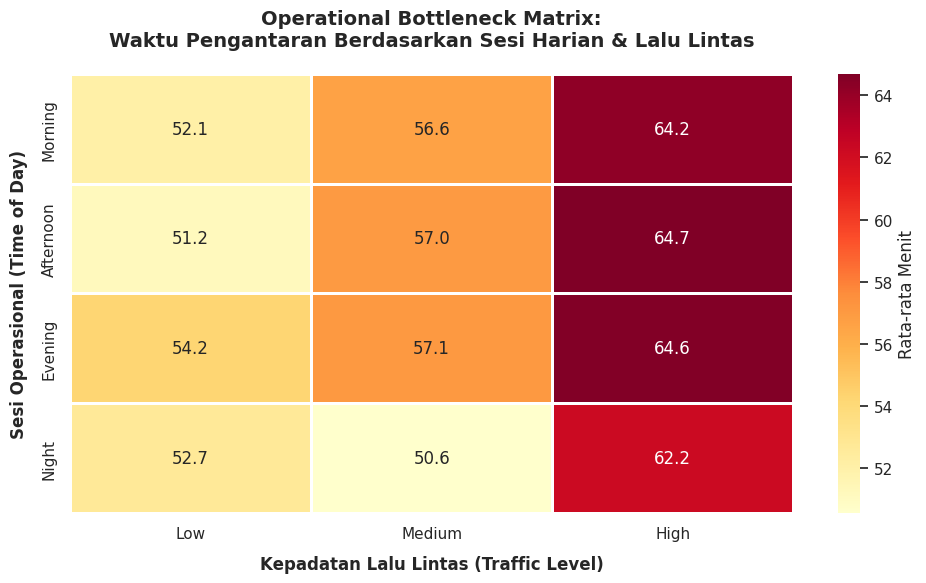

In [3]:
# ==========================================
# 1. IMPORT LIBRARIES & DOWNLOAD DATA
# ==========================================
!pip install -q kagglehub
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("Mengunduh dataset dari Kaggle...")
dataset_path = kagglehub.dataset_download("denkuznetz/food-delivery-time-prediction")
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
file_path = csv_files[0]

df = pd.read_csv(file_path)
print(f"Dimensi Data Mentah: {df.shape}")

# ==========================================
# 2. DATA PREPROCESSING & CLEANING
# ==========================================
# Standarisasi string (menghapus spasi berlebih)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# MENGATASI BUG 'nan': Menghapus baris teks 'nan'
df = df[(df['Weather'] != 'nan') & (df['Traffic_Level'] != 'nan') &
        (df['Time_of_Day'] != 'nan') & (df['Vehicle_Type'] != 'nan')]

# Menangani missing values bawaan sistem dan duplikasi
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Feature Engineering
df['Transit_Time_min'] = df['Delivery_Time_min'] - df['Preparation_Time_min']
df['Speed_Index_min_per_km'] = df['Transit_Time_min'] / df['Distance_km']

# Filter anomali operasional (waktu tidak logis / minus)
df = df[df['Transit_Time_min'] > 0].copy()

print(f"Dimensi Data Bersih Siap Analisis: {df.shape}")

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# -- VISUAL 1: TRAFFIC LEVEL (Boxplot) --
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4.5))
traffic_order = ['Low', 'Medium', 'High', 'Jam']
valid_traffic = [t for t in traffic_order if t in df['Traffic_Level'].unique()]
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df, order=valid_traffic, palette='crest')
plt.title('Pengaruh Kepadatan Lalu Lintas terhadap Total Waktu Pengantaran', fontsize=12, fontweight='bold')
plt.xlabel('Kepadatan Lalu Lintas')
plt.ylabel('Total Waktu (Menit)')
plt.tight_layout()
plt.savefig('visual_traffic.png', dpi=300)

# -- VISUAL 2: WEATHER (Barplot) --
plt.figure(figsize=(8, 4.5))
weather_order = df.groupby('Weather')['Delivery_Time_min'].mean().sort_values().index
sns.barplot(x='Weather', y='Delivery_Time_min', data=df, order=weather_order, palette='mako', errorbar=None)
plt.title('Rata-Rata Waktu Pengantaran Berdasarkan Cuaca', fontsize=12, fontweight='bold')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-Rata Waktu (Menit)')
plt.tight_layout()
plt.savefig('visual_weather.png', dpi=300)

# -- VISUAL 3: DISTANCE (Scatterplot) --
plt.figure(figsize=(8, 4.5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', hue='Traffic_Level', data=df, hue_order=valid_traffic, palette='viridis', alpha=0.7)
plt.title('Hubungan Jarak Pengiriman vs Waktu Pengantaran', fontsize=12, fontweight='bold')
plt.xlabel('Jarak Tempuh (km)')
plt.ylabel('Total Waktu (Menit)')
plt.legend(title='Traffic Level')
plt.tight_layout()
plt.savefig('visual_distance.png', dpi=300)

# -- VISUAL 4: OPERATIONAL BOTTLENECK (Heatmap) --
heatmap_data = df.pivot_table(index='Time_of_Day', columns='Traffic_Level', values='Delivery_Time_min', aggfunc='mean')
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
heatmap_data = heatmap_data.reindex(index=[t for t in time_order if t in heatmap_data.index],
                                    columns=[t for t in traffic_order if t in heatmap_data.columns])

plt.figure(figsize=(10, 6))
sns.set_theme(style="white") # Background bersih khusus heatmap
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=1, linecolor='white', cbar_kws={'label': 'Rata-rata Menit'})
plt.title("Operational Bottleneck Matrix:\nWaktu Pengantaran Berdasarkan Sesi Harian & Lalu Lintas", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Kepadatan Lalu Lintas (Traffic Level)", fontweight='bold', labelpad=10)
plt.ylabel("Sesi Operasional (Time of Day)", fontweight='bold', labelpad=10)
plt.tight_layout()
plt.savefig('executive_heatmap.png', dpi=300)

# ==========================================
# 4. EXPORT & DOWNLOAD OTOMATIS
# ==========================================
clean_filename = 'cleaned_food_delivery.csv'
df.to_csv(clean_filename, index=False)
print("Analisis Selesai! Mengunduh file CSV dan 4 gambar grafik ke laptop...")

files.download(clean_filename)
files.download('visual_traffic.png')
files.download('visual_weather.png')
files.download('visual_distance.png')
files.download('executive_heatmap.png')

In [5]:
import pandas as pd
import numpy as np
import kagglehub
import os
import glob
from google.colab import files

# 1. Load data ulang dari dataset
dataset_path = kagglehub.dataset_download("denkuznetz/food-delivery-time-prediction")
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))
df = pd.read_csv(csv_files[0])

# 2. Pembersihan String & Penanganan 'nan' secara agresif
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Menghapus seluruh baris yang mengandung variasi nilai kosong atau 'nan'
bad_values = ['nan', 'NaN', 'None', '', '?', 'null']
for col in df.columns:
    if df[col].dtype == 'object':
        df = df[~df[col].isin(bad_values)]

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# 3. Normalisasi Jarak (Distance_km) agar desimalnya terbaca dengan benar oleh Excel/Power BI
# Jika jarak aslinya terbaca ribuan karena faktor titik desimal, kita bagi 100 atau konversi float yang tepat:
if df['Distance_km'].max() > 50:
    df['Distance_km'] = df['Distance_km'] / 100.0

# 4. Feature Engineering Tambahan
df['Transit_Time_min'] = df['Delivery_Time_min'] - df['Preparation_Time_min']
df = df[df['Transit_Time_min'] > 0].copy()

# 5. Export file bersih terbaru
clean_filename = 'cleaned_food_delivery_v2.csv'
df.to_csv(clean_filename, index=False)
print(f"Data bersih siap! Total baris valid: {len(df)}")

# Download otomatis ke laptop
files.download(clean_filename)

Using Colab cache for faster access to the 'food-delivery-time-prediction' dataset.
Data bersih siap! Total baris valid: 883


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>